In [2]:
import numpy as np
import glob
import lgdo.lh5 as lh5
import os, json
import copy
import glob
import matplotlib.pyplot as plt
from pygama.pargen.utils import load_data
from legendmeta import LegendMetadata
from dbetto import Props, TextDB, AttrsDict
import pandas as pd
from tqdm.notebook import tqdm
import awkward as ak

from helper_lib import *

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [3]:
period = 'p03'
run = 'r003'
version = "v2.1.4"
base = f"/global/cfs/projectdirs/m2676/data/lngs/l200/public/prodenv/prod-blind/ref/{version}/"
config = Props.read_from(base+"/config.json", subst_pathvar=True)['setups']['l200']['paths']

scratch_folder = "/pscratch/sd/b/borrfran/sim-v1.1.0-20260401/"

meta = LegendMetadata(config['metadata'])

timestamp = meta.dataprod.runinfo.p03.r003.phy.start_key

chmap = meta.channelmap(timestamp)

ges = [ge for ge in chmap.group('system')['geds'].map("name").keys() 
    # if chmap[ge]['analysis']['processable'] and chmap[ge]['analysis']['usability'] == 'on'
      ]

rawids_map = get_rawids_map(chmap, ges) 

simulated_energies = range(200, 1100, 100)

## read all the data

In [ ]:
energies = range(200, 1100, 100)

fig, ax = plt.subplots(figsize=(16, 7))  # larghezza generosa per spaziatura
values_dict = {}
total_dict = {}

for ene in tqdm(energies):
    tag = f"{ene}keV"
    
    job_string = f"electron_{tag}_hpge_bulk"

    cvt_file = glob.glob(f"./tier/cvt/l200cfg01-{job_string}-tier_cvt.lh5")[0]
    print(cvt_file)
    stp_files = glob.glob(f"{scratch_folder}/generated/tier/stp/{job_string}/l200cfg01-{job_string}-job_*-tier_stp.lh5")

    det_ene = riempi_dict(cvt_file, ges, chmap, stp_files, ene, thr)
    
    total_dict[ene] = det_ene
    
    keys, values = prendi_valori(det_ene)
    values_dict[ene] = values
    ax.scatter(keys, values, marker = 'o', label=tag)


plt.xticks(ticks=range(len(keys)), labels=keys, rotation=90, ha='center')

ax.set_ylabel("N_counts_in_FEP/N_primaries")
ax.margins(x=0.02)  # riduce il padding laterale (default è 0.05)
ax.set_ylim(0.5, 1)
plt.legend()
# Padding sotto per non tagliare le etichette
plt.tight_layout()
plt.savefig("./plots/fully_contained_efficiency.png", dpi=500)
plt.show()

    

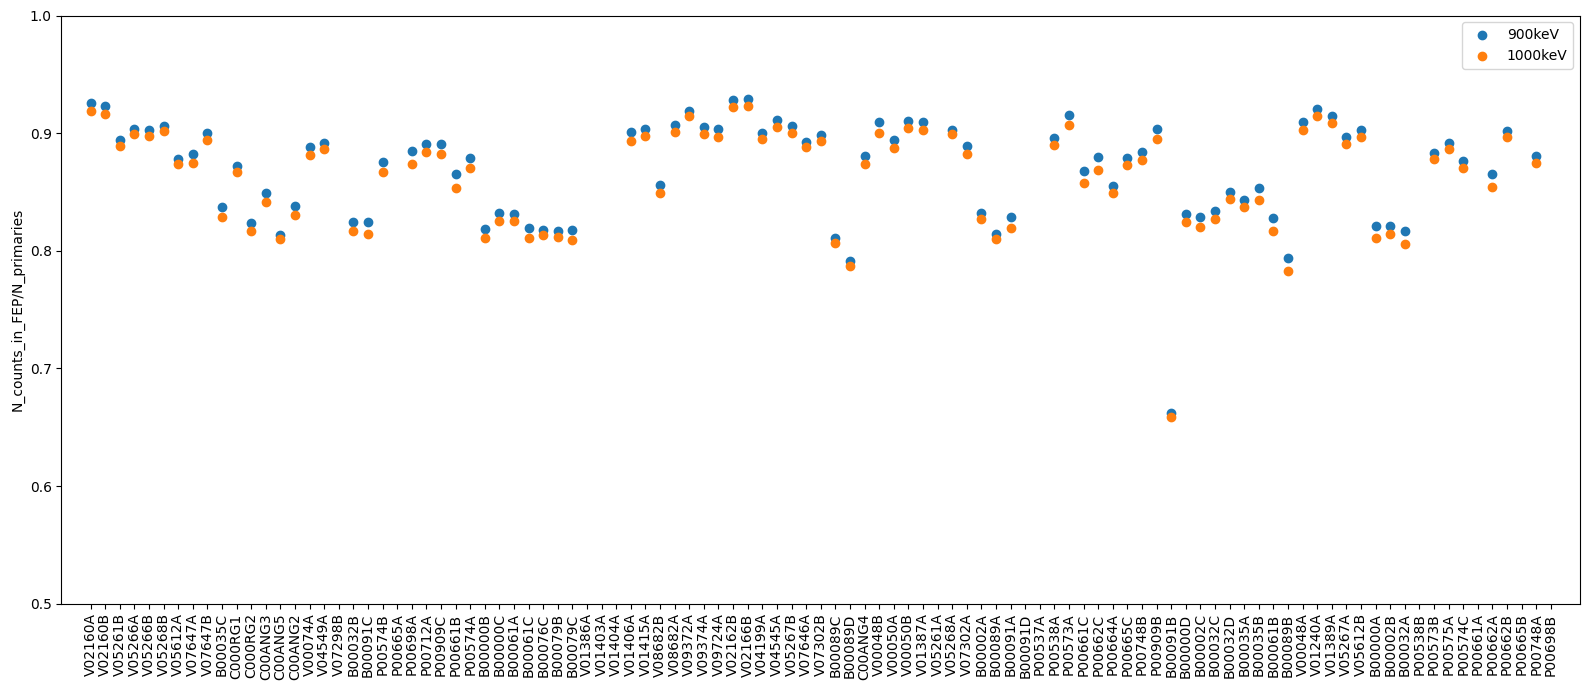

In [9]:
energies = range(200, 1100, 100)

fig, ax = plt.subplots(figsize=(16, 7))  # larghezza generosa per spaziatura

keys = ges

for ene in energies[-2:]:
    tag = f"{ene}keV"
    
    values = values_dict[ene]
    ax.scatter(keys, values, marker = 'o', label=tag)


plt.xticks(ticks=range(len(keys)), labels=keys, rotation=90, ha='center')

ax.set_ylabel("N_counts_in_FEP/N_primaries")
ax.margins(x=0.02)  # riduce il padding laterale (default è 0.05)
ax.set_ylim(0.5, 1)
plt.legend()
# Padding sotto per non tagliare le etichette
plt.tight_layout()
# plt.savefig("notebooks/plots/fully_contained_efficiency.png", dpi=500)
plt.show()



## Data in dict

In [54]:
tot_dict = Props.read_from('./v1/dictionaries/first.yaml')

## some plots

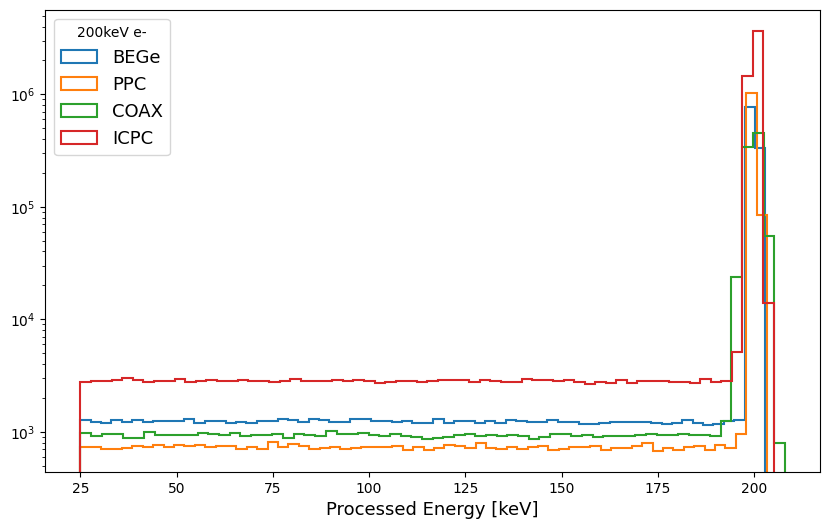

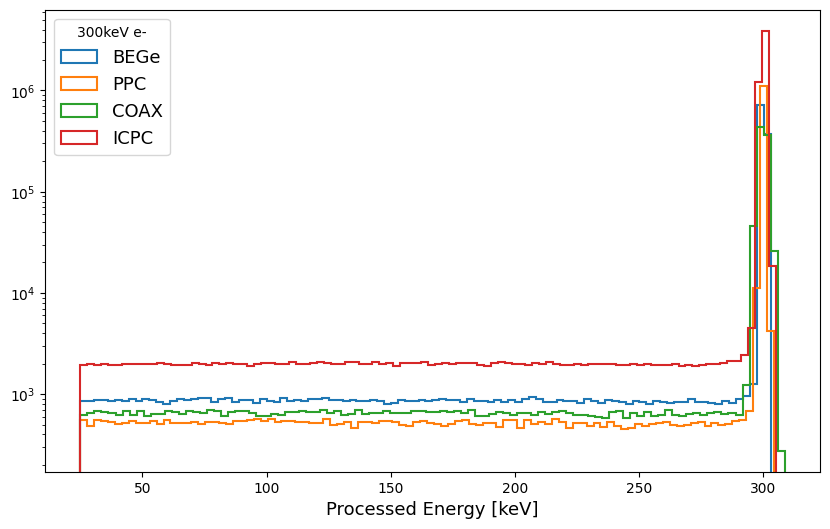

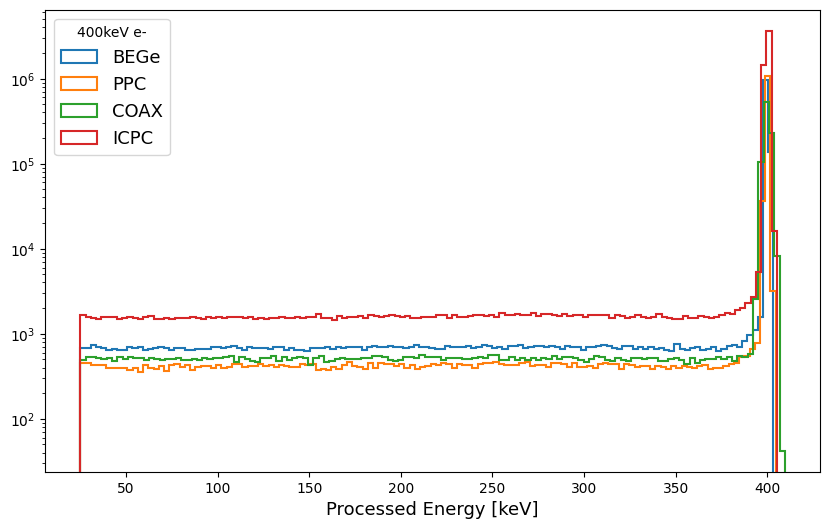

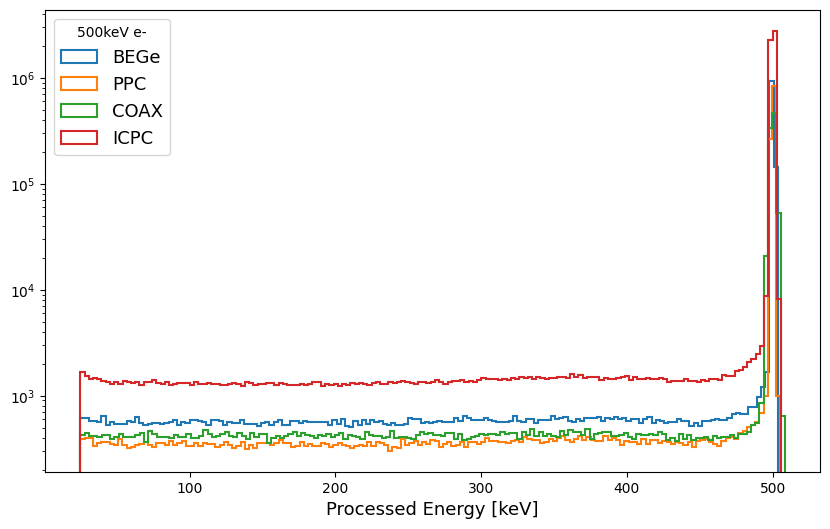

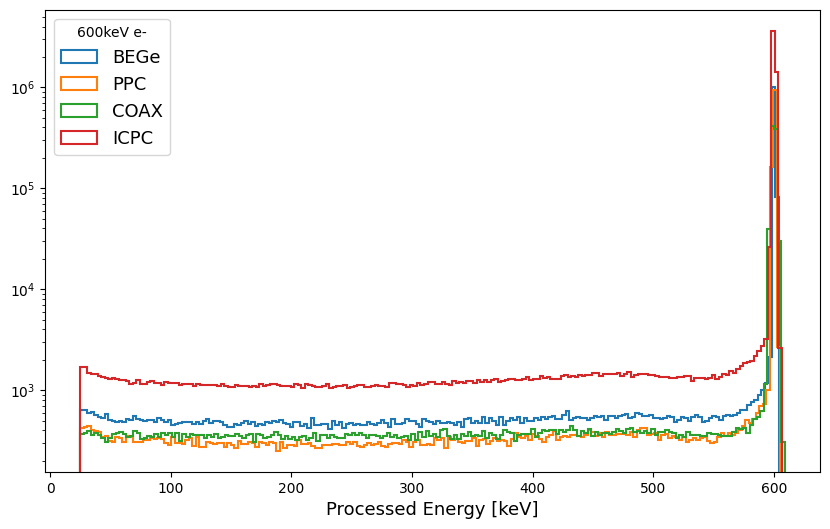

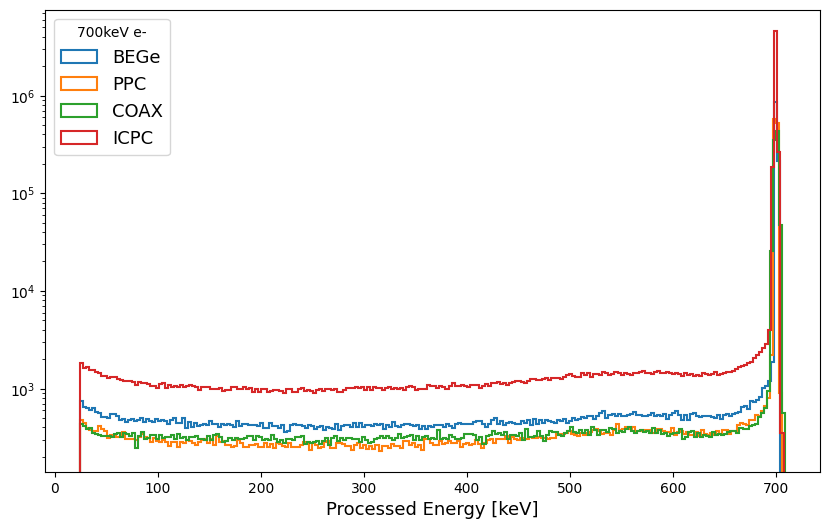

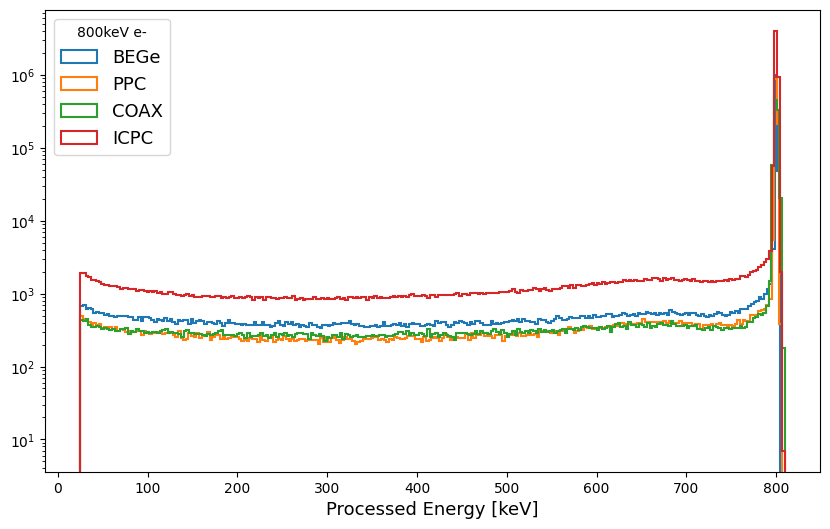

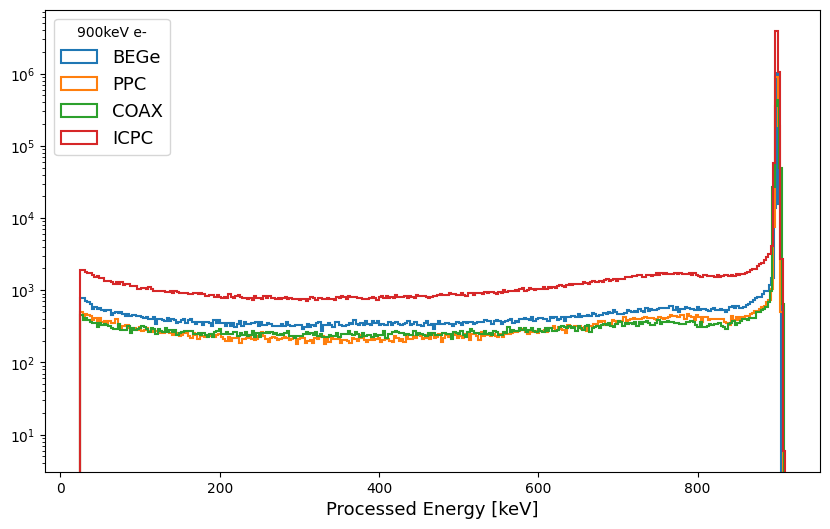

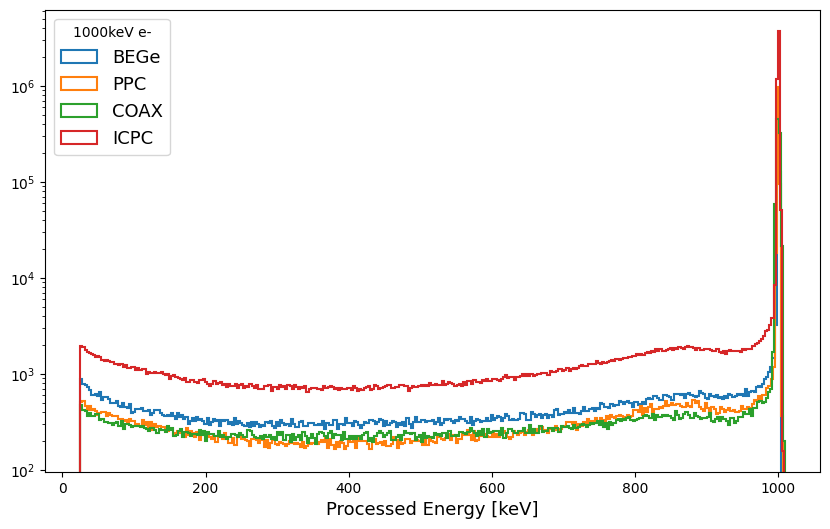

In [27]:
ges_sorted = sorted(list(dict2[200].keys()))

for ene in dict2.keys():
    ene_dict = dict2[ene]
    plot_e_det_type(ene_dict, ene, bins = int(ene/3), lw = 1.5)

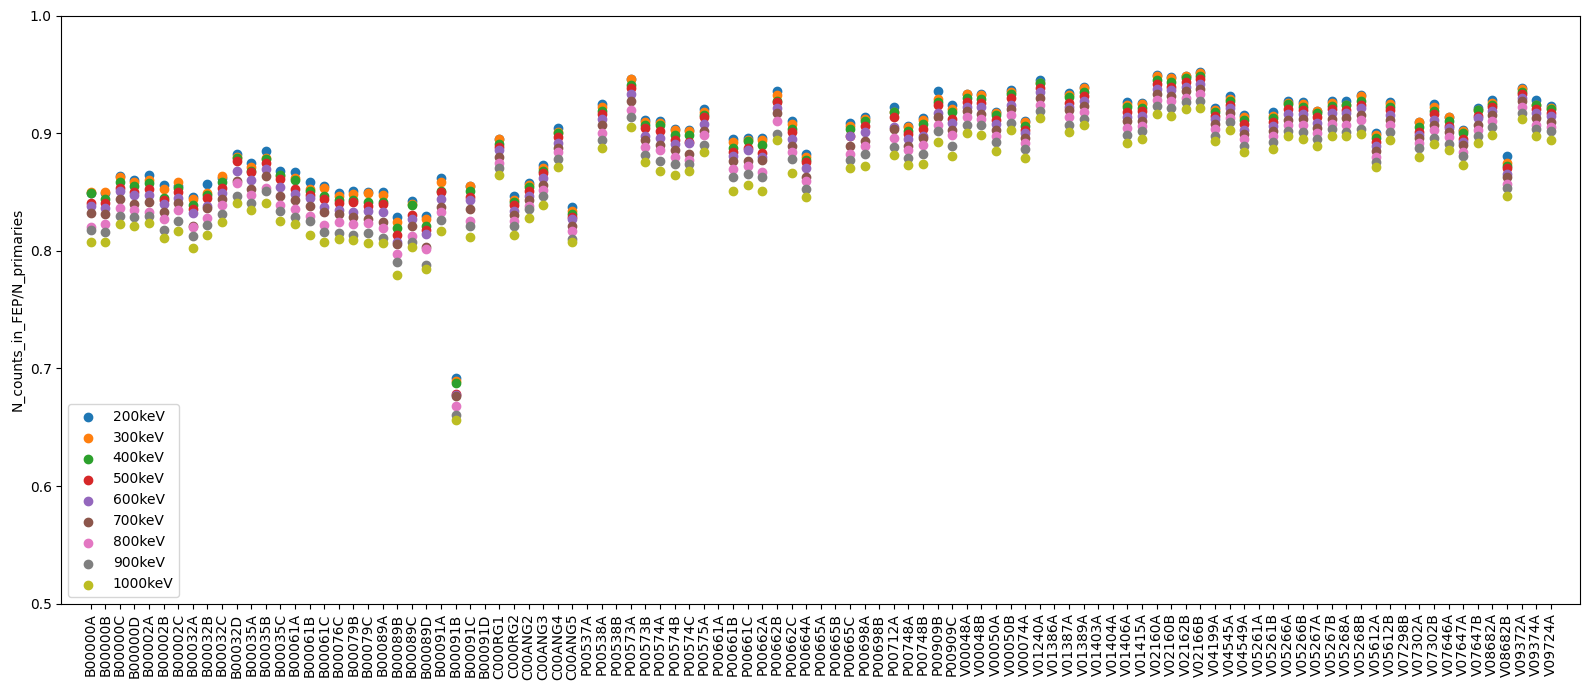

In [34]:
fig, ax = plt.subplots(figsize=(16, 7))  # larghezza generosa per spaziatura

for ene in dict2.keys():

    values, x = get_values_sorted(dict2[ene], ges_sorted)
    
    tag = f"{ene}keV"
    
    ax.scatter(x, values, marker = 'o', label=tag)


plt.xticks(ticks=range(len(x)), labels=x, rotation=90, ha='center')

ax.set_ylabel("N_counts_in_FEP/N_primaries")
ax.margins(x=0.02)  # riduce il padding laterale (default è 0.05)
ax.set_ylim(0.5, 1)
plt.legend()
# Padding sotto per non tagliare le etichette
plt.tight_layout()
plt.savefig("./plots/fully_contained_efficiency_sorted.png", dpi=500)
plt.show()



In [ ]:
# fig, ax = plt.subplots(figsize=(16, 7))  # larghezza generosa per spaziatura

# for ene in dict2.keys():

#     values, x = get_values_type(tot_dict[ene], ges_sorted)
    
#     tag = f"{ene}keV"
    
#     ax.scatter(x, values, marker = 'o', label=tag)


# plt.xticks(ticks=range(len(x)), labels=x, rotation=90, ha='center')

# ax.set_ylabel("N_counts_in_FEP/N_primaries")
# ax.margins(x=0.02)  # riduce il padding laterale (default è 0.05)
# ax.set_ylim(0.5, 1)
# plt.legend()
# # Padding sotto per non tagliare le etichette
# plt.tight_layout()
# plt.savefig("./plots/fully_contained_efficiency_sorted.png", dpi=500)
# plt.show()



## study for B00091B

In [73]:
from matplotlib.backends.backend_pdf import PdfPages

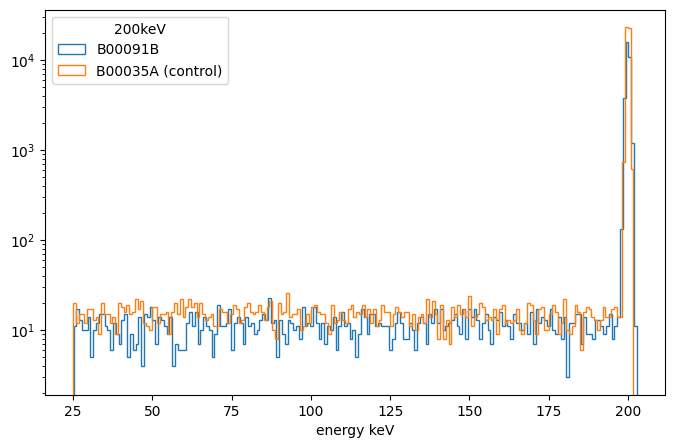

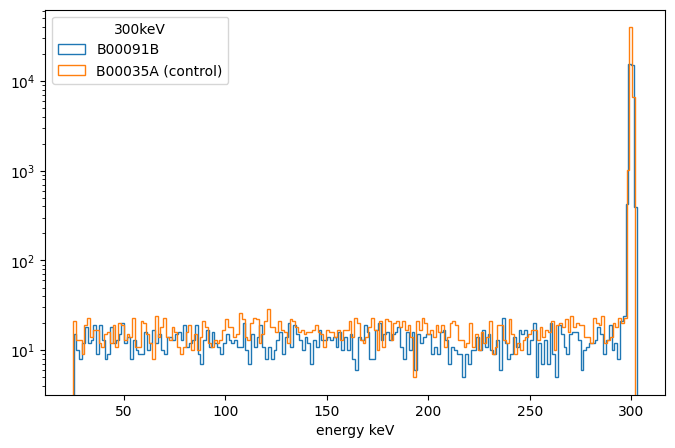

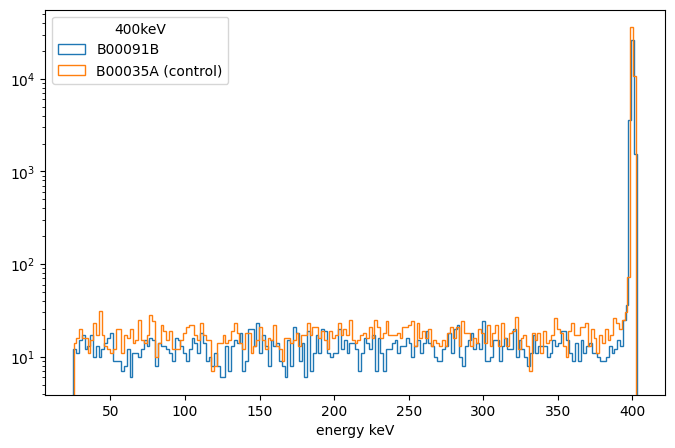

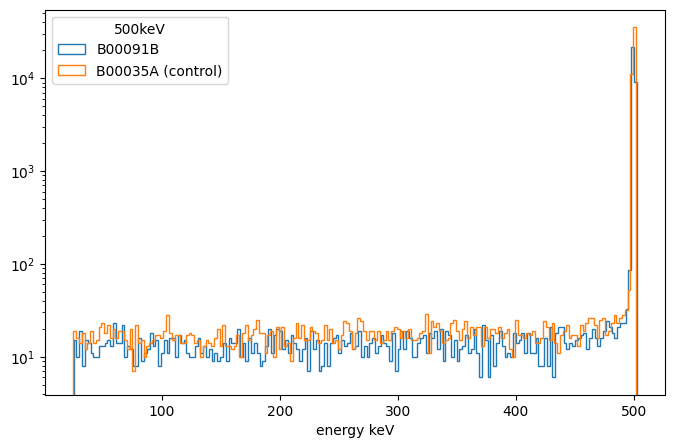

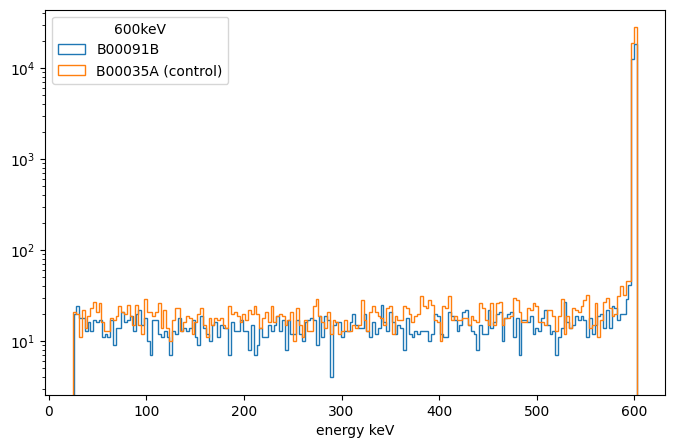

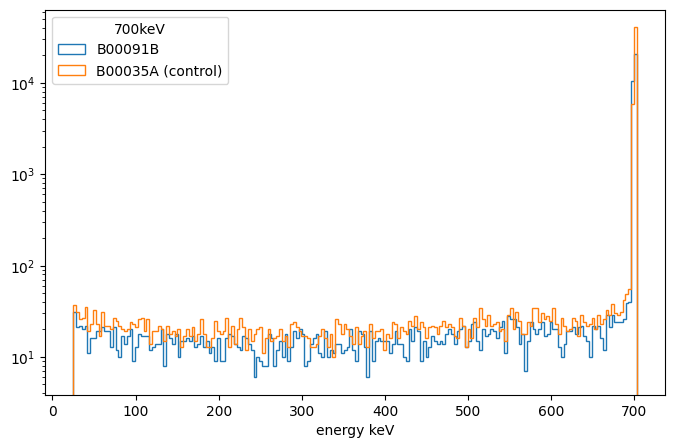

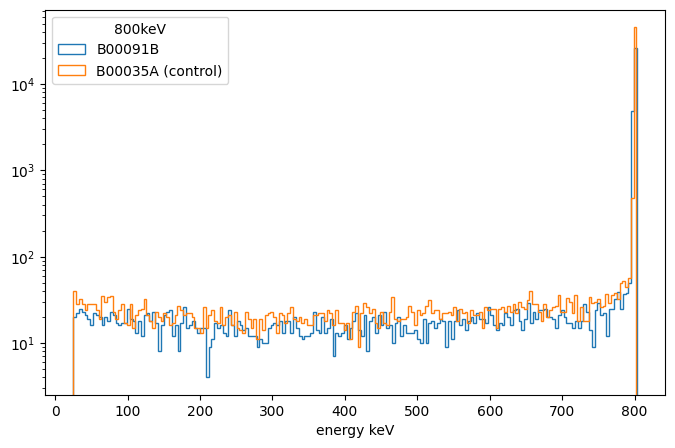

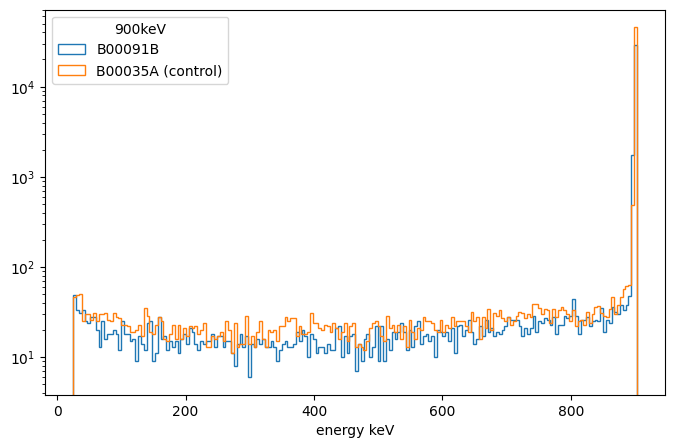

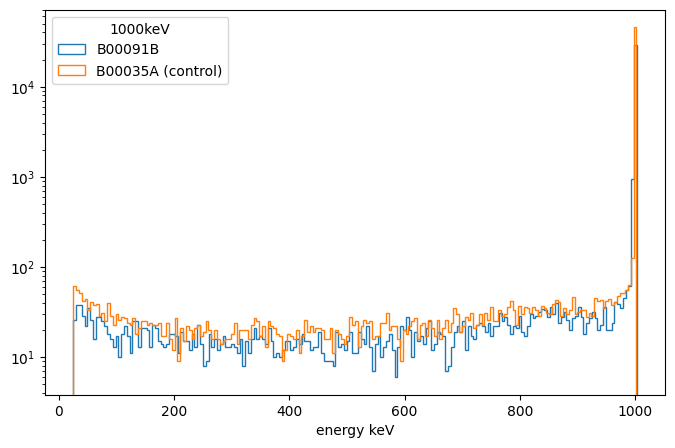

In [75]:
with PdfPages('./plots/output.pdf') as pdf:
    for ene in simulated_energies:
    
        tag = f"{ene}keV"
        job_string = f"electron_{tag}_hpge_bulk"
        
        cvt_file = glob.glob(f"./v1/tiers/cvt/l200cfg01-{job_string}-tier_cvt.lh5")[0]
        
        # how_many[ene] = {}
        
        data = lh5.read_as(f"evt", cvt_file, field_mask=["coincident", "geds", "trigger"], library = 'ak')
    
        energies = ak.flatten(data.geds.energy[data.geds.multiplicity == 1])
        channels = ak.flatten(data.geds.rawid[data.geds.multiplicity == 1])
        
        # read B00091B data
        B91B_raw = chmap['B00091B'].daq.rawid
        B91B_energies = energies[channels == B91B_raw]
        
        # control B00035A
        B35A_raw = chmap['B00035A'].daq.rawid
        B35A_energies = select_channel(energies, channels, B35A_raw)
    
        #plot spectra
        plt.figure(figsize=(8,5))
        plt.hist(B91B_energies, bins = 200, histtype='step', label = 'B00091B')
        plt.hist(B35A_energies, bins = 200, histtype='step', label = 'B00035A (control)')
        
        plt.yscale('log')
        plt.xlabel('energy keV')
        plt.legend(title=tag)
        pdf.savefig()
        plt.show()

In [76]:
usabilities = Props.read_from(f'{scratch_folder}/generated/pars/detector_usabilities.yaml')
usabilities

{'l200-p03-r000-phy': {'V02160A': 'on',
  'V02160B': 'on',
  'V05261B': 'on',
  'V05266A': 'on',
  'V05266B': 'on',
  'V05268B': 'on',
  'V05612A': 'on',
  'V07647A': 'on',
  'V07647B': 'on',
  'B00035C': 'on',
  'C000RG1': 'on',
  'C000RG2': 'on',
  'C00ANG3': 'on',
  'C00ANG5': 'on',
  'C00ANG2': 'on',
  'V00074A': 'ac',
  'V04549A': 'on',
  'V07298B': 'off',
  'B00032B': 'on',
  'B00091C': 'on',
  'P00574B': 'on',
  'P00665A': 'off',
  'P00698A': 'on',
  'P00712A': 'ac',
  'P00909C': 'ac',
  'P00661B': 'on',
  'P00574A': 'on',
  'B00000B': 'on',
  'B00000C': 'on',
  'B00061A': 'on',
  'B00061C': 'on',
  'B00076C': 'on',
  'B00079B': 'on',
  'B00079C': 'on',
  'V01386A': 'off',
  'V01403A': 'off',
  'V01404A': 'off',
  'V01406A': 'ac',
  'V01415A': 'ac',
  'V08682B': 'on',
  'V08682A': 'on',
  'V09372A': 'on',
  'V09374A': 'on',
  'V09724A': 'on',
  'V02162B': 'on',
  'V02166B': 'on',
  'V04199A': 'on',
  'V04545A': 'on',
  'V05267B': 'ac',
  'V07646A': 'on',
  'V07302B': 'on',
  'B0

# df analysis

In [4]:
full_df = pd.DataFrame()
for ene in tqdm(simulated_energies):

    tag = f"{ene}keV"
    job_string = f"electron_{tag}_hpge_bulk"
    
    cvt_file = glob.glob(f"./v1/tiers/cvt/l200cfg01-{job_string}-tier_cvt.lh5")[0]
    
    # how_many[ene] = {}
    
    data = lh5.read_as(f"evt", cvt_file, field_mask=["coincident", "geds", "trigger"], library = 'ak')
    
    tmp  = data.geds[data.geds.multiplicity == 1]
    tmp2 = data.trigger[data.geds.multiplicity == 1]
    df = ak_to_pandas(tmp, tmp2)
    df['sim_e'] = np.full(len(df), ene, dtype=int)
    
    full_df = pd.concat([full_df, df], ignore_index=True)
    

  0%|          | 0/9 [00:00<?, ?it/s]

In [61]:
pl_df

energy,energy_sum,hit_idx,is_good_channel,is_single_site,multiplicity,rawid,evtid,period,run,sim_e
f64,f64,i64,bool,bool,i64,i64,f64,f64,f64,i64
199.774142,199.774142,0,true,false,1,1084804,0.0,3.0,0.0,200
200.157679,200.157679,0,true,false,1,1113605,3.0,3.0,0.0,200
200.132685,200.132685,0,true,false,1,1110403,4.0,3.0,0.0,200
199.554582,199.554582,0,true,true,1,1120002,5.0,3.0,0.0,200
199.286528,199.286528,0,true,false,1,1121604,6.0,3.0,0.0,200
…,…,…,…,…,…,…,…,…,…,…
1001.442346,0.0,12325,false,false,1,1112001,1.999993e6,9.0,5.0,1000
1000.667713,1000.667713,34587,true,true,1,1118402,1.999995e6,9.0,5.0,1000
1001.673265,1001.673265,14828,true,false,1,1080005,1.999996e6,9.0,5.0,1000


## Get # primaries per detector

In [10]:
prim_dict = {}

for ene in simulated_energies:

    tag = f"{ene}keV"
    job_string = f"electron_{tag}_hpge_bulk"
    stp_files = glob.glob(f"{scratch_folder}/generated/tier/stp/{job_string}/l200cfg01-{job_string}-job_*-tier_stp.lh5")

    prim_dict[ene] = get_n_primaries(ges, stp_files)

  0%|          | 0/101 [00:00<?, ?it/s]

  0%|          | 0/101 [00:00<?, ?it/s]

  0%|          | 0/101 [00:00<?, ?it/s]

  0%|          | 0/101 [00:00<?, ?it/s]

  0%|          | 0/101 [00:00<?, ?it/s]

  0%|          | 0/101 [00:00<?, ?it/s]

  0%|          | 0/101 [00:00<?, ?it/s]

  0%|          | 0/101 [00:00<?, ?it/s]

  0%|          | 0/101 [00:00<?, ?it/s]

In [76]:
ene = 200
high = ene + fwhm
low = ene - fwhm

for ge in ges:
    if ge[0]!='V': continue
    
    rawid = chmap[ge].daq.rawid
    print(ge, rawid)
    
    df_filtered = pl_df.filter(
                (pl.col("rawid") == rawid) &
                (pl.col("is_good_channel")) &
                (pl.col("sim_e") == ene)
            )
    df_fep = df_filtered.filter(
            pl.col("energy").is_between(low, high)
        )

    print(len(df_filtered), len(df_fep))
    print('======================\n')

V02160A 1104000
119955 117187

V02160B 1104001
117548 114756

V05261B 1104002
159158 153208

V05266A 1104003
138753 134204

V05266B 1104004
133309 128808

V05268B 1104005
120329 116574

V05612A 1105600
145068 138318

V07647A 1105602
125872 120235

V07647B 1105603
119895 115618

V00074A 1108802
0 0

V04549A 1108803
129483 124508

V07298B 1108804
0 0

V01386A 1115200
0 0

V01403A 1115201
0 0

V01404A 1115202
0 0

V01406A 1115203
0 0

V01415A 1115204
0 0

V08682B 1116801
98736 93238

V08682A 1116802
217120 210037

V09372A 1116803
274493 266753

V09374A 1116804
178036 172153

V09724A 1116805
176529 170348

V02162B 1118402
168398 164452

V02166B 1118403
180394 176512

V04199A 1118404
200589 193481

V04545A 1118405
204498 198147

V05267B 1120000
0 0

V07646A 1120001
173995 167092

V07302B 1120002
106322 102660

V00048B 1121600
122738 119022

V00050A 1121601
126928 122283

V00050B 1121602
127027 123321

V01387A 1121603
0 0

V05261A 1121604
44259 42903

V05268A 1121605
153213 148171

V07302A 1

In [82]:
ratio_dict = {}
fwhm = 5
for ene in tqdm(simulated_energies):
    ratio_dict[ene] = {}
    high = ene + fwhm
    low = ene - fwhm
    
    for ge in ges:

        rawid = chmap[ge].daq.rawid
        
        # n_evts = len(full_df.query('energy<@high and energy>@low and rawid==@rawid'))
        df_filtered = pl_df.filter(
                    (pl.col("rawid") == rawid) &
                    (pl.col("is_good_channel")) &
                    (pl.col("sim_e") == ene)
                )
        df_fep = df_filtered.filter(
                pl.col("energy").is_between(low, high)
            )
        
        n_evts = len(df_fep)
        # n_primaries = prim_dict[ene][ge]
        n_primaries = len(df_filtered)
            
        ratio_dict[ene][ge] = {}
        ratio_dict[ene][ge]['n_events'] = n_evts
        ratio_dict[ene][ge]['n_primaries'] = n_primaries
        if n_primaries == 0:
            ratio_dict[ene][ge]['ratio'] = np.nan
        else: 
            ratio_dict[ene][ge]['ratio'] = n_evts/n_primaries

  0%|          | 0/9 [00:00<?, ?it/s]

In [83]:
ratio_dict[ene]

{'V02160A': {'n_events': 113630,
  'n_primaries': 121148,
  'ratio': 0.9379436722025952},
 'V02160B': {'n_events': 110379,
  'n_primaries': 117622,
  'ratio': 0.9384213837547397},
 'V05261B': {'n_events': 148994,
  'n_primaries': 160970,
  'ratio': 0.9256010436727341},
 'V05266A': {'n_events': 131016,
  'n_primaries': 140651,
  'ratio': 0.9314971098676866},
 'V05266B': {'n_events': 125229,
  'n_primaries': 134734,
  'ratio': 0.9294535900366648},
 'V05268B': {'n_events': 112921,
  'n_primaries': 121243,
  'ratio': 0.9313609857888703},
 'V05612A': {'n_events': 134649,
  'n_primaries': 146525,
  'ratio': 0.918948984814878},
 'V07647A': {'n_events': 116332,
  'n_primaries': 126807,
  'ratio': 0.9173941501652118},
 'V07647B': {'n_events': 111202,
  'n_primaries': 120378,
  'ratio': 0.9237734469753609},
 'B00035C': {'n_events': 37452,
  'n_primaries': 42345,
  'ratio': 0.8844491675522493},
 'C000RG1': {'n_events': 123154,
  'n_primaries': 136680,
  'ratio': 0.9010389230318994},
 'C000RG2': {

In [ ]:
fig, ax = plt.subplots(figsize=(16, 7))  # larghezza generosa per spaziatura

keys = ges

for ene in energies[-2:]:
    tag = f"{ene}keV"
    
    values = ratio_dict[ene]
    ax.scatter(keys, values, marker = 'o', label=tag)


plt.xticks(ticks=range(len(keys)), labels=keys, rotation=90, ha='center')

ax.set_ylabel("N_counts_in_FEP/N_primaries")
ax.margins(x=0.02)  # riduce il padding laterale (default è 0.05)
ax.set_ylim(0.5, 1)
plt.legend()
# Padding sotto per non tagliare le etichette
plt.tight_layout()
# plt.savefig("notebooks/plots/fully_contained_efficiency.png", dpi=500)
plt.show()


In [84]:
ratio_dict

{200: {'V02160A': {'n_events': 117209,
   'n_primaries': 119955,
   'ratio': 0.9771080821974907},
  'V02160B': {'n_events': 114784,
   'n_primaries': 117548,
   'ratio': 0.9764862013815633},
  'V05261B': {'n_events': 153245,
   'n_primaries': 159158,
   'ratio': 0.9628482388569849},
  'V05266A': {'n_events': 134237,
   'n_primaries': 138753,
   'ratio': 0.9674529559721231},
  'V05266B': {'n_events': 128831,
   'n_primaries': 133309,
   'ratio': 0.9664088696187054},
  'V05268B': {'n_events': 116602,
   'n_primaries': 120329,
   'ratio': 0.9690265854449052},
  'V05612A': {'n_events': 138361,
   'n_primaries': 145068,
   'ratio': 0.9537665094989936},
  'V07647A': {'n_events': 120269,
   'n_primaries': 125872,
   'ratio': 0.9554865259946612},
  'V07647B': {'n_events': 115648,
   'n_primaries': 119895,
   'ratio': 0.9645773385045248},
  'B00035C': {'n_events': 38888,
   'n_primaries': 41399,
   'ratio': 0.9393463610232131},
  'C000RG1': {'n_events': 128119,
   'n_primaries': 136105,
   'rat

In [85]:
ratio_dict_means = get_mean_fcc_det_type(ratio_dict)

In [86]:
B = []
C = []
I = []
P = []

for ene in ratio_dict_means.keys():

    B.append(ratio_dict_means[ene]['BEGe'])
    I.append(ratio_dict_means[ene]['ICPC'])
    C.append(ratio_dict_means[ene]['COAX'])
    P.append(ratio_dict_means[ene]['PPC'])

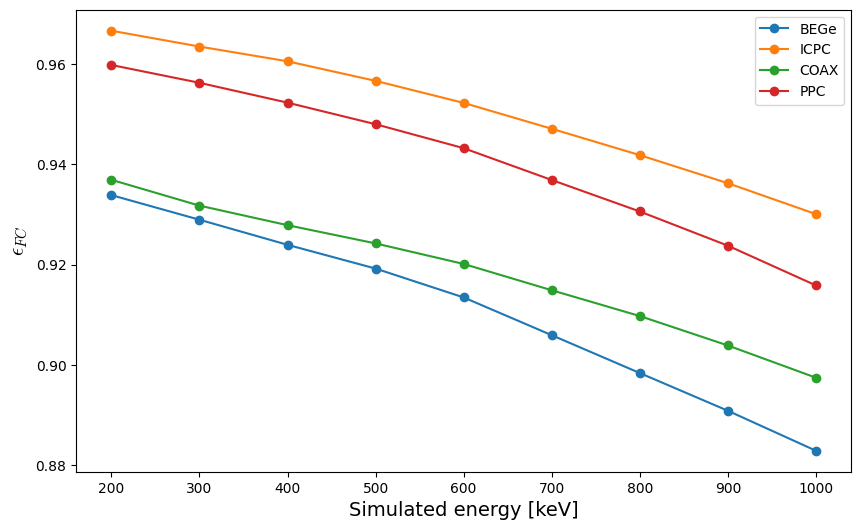

In [94]:
x = ratio_dict_means.keys()
plt.rcParams["mathtext.fontset"] = "cm"
plt.figure(figsize=(10,6))

plt.plot(x, B, marker = 'o', label = 'BEGe')
plt.plot(x, I, marker = 'o', label = 'ICPC')
plt.plot(x, C, marker = 'o', label = 'COAX')
plt.plot(x, P, marker = 'o', label = 'PPC')

plt.xlabel('Simulated energy [keV]', fontsize = 14)
plt.ylabel(r"$\epsilon_{FC}$", fontsize = 15)
plt.legend()
plt.savefig('./plots/FC_eff_det_type.png', dpi = 500)
plt.show()

  0%|          | 0/9 [00:00<?, ?it/s]

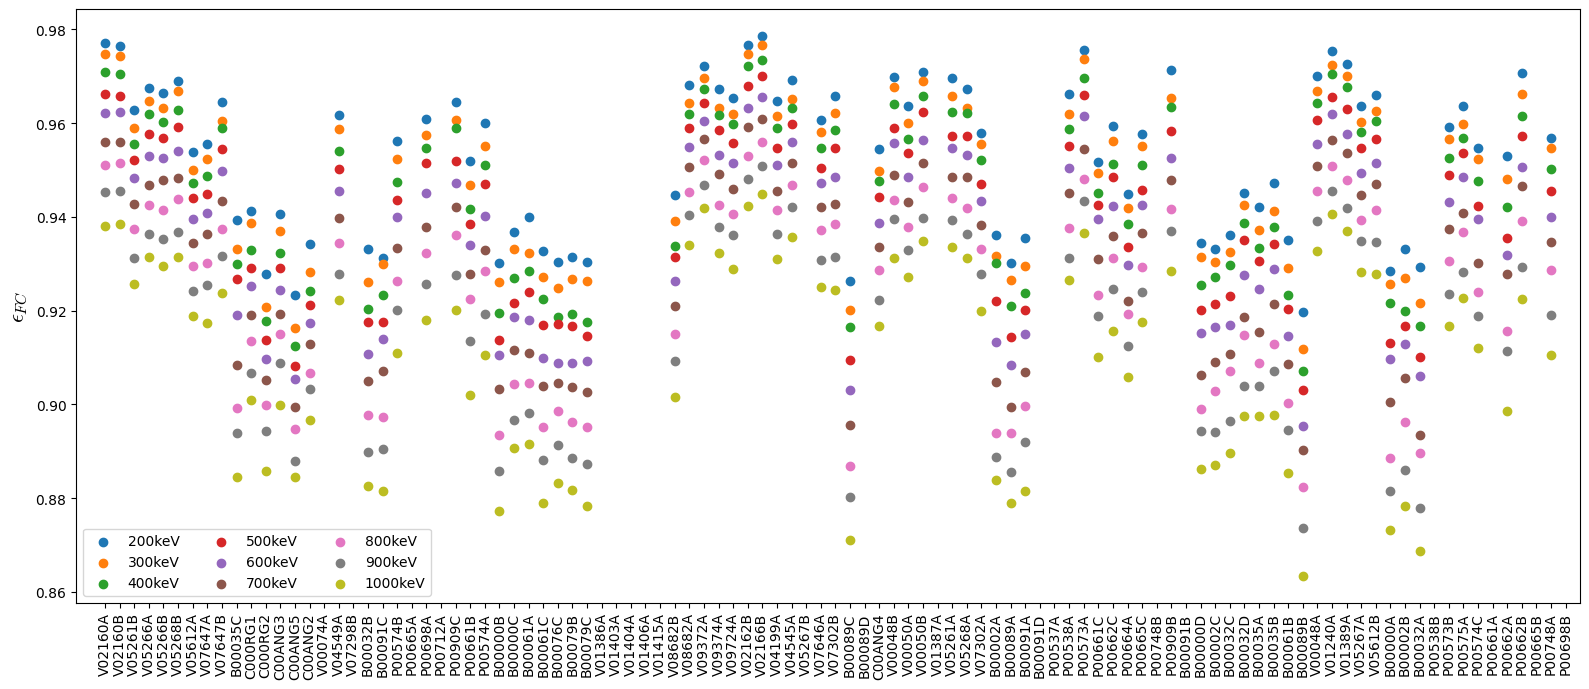

In [106]:
values_dict = {}

fig, ax = plt.subplots(figsize=(16, 7))  # larghezza generosa per spaziatura

for ene in tqdm(simulated_energies):
    
    keys, values = prendi_valori(ratio_dict[ene])
    values_dict[ene] = values
    tag = f'{ene}keV'
    ax.scatter(keys, values, marker = 'o', label=tag)


plt.xticks(ticks=range(len(keys)), labels=keys, rotation=90, ha='center')

ax.set_ylabel(r"$\epsilon_{FC}$", fontsize = 16)
ax.margins(x=0.02)  # riduce il padding laterale (default è 0.05)
# ax.set_ylim(0.75, 1)
plt.legend(ncol = 3)
# Padding sotto per non tagliare le etichette
plt.tight_layout()
plt.savefig("./plots/fully_contained_efficiency.png", dpi=500)
plt.show()


In [17]:
import polars as pl

In [18]:
pl_df = pl.from_pandas(full_df, include_index=False)

In [23]:
!ls

data.parquet  do_smth.ipynb  helper_lib.py  plots  __pycache__	v1


In [22]:
pl_df.write_parquet(
    "data.parquet",
    compression="zstd",
    statistics=True
)

In [53]:
data.trigger.fields

['evtid', 'period', 'run', 'timestamp']

In [61]:
rawid = rawids_map['B00091B']
sel_df = full_df.query('rawid==@B35A_id')
sel_df

,energy,energy_sum,hit_idx,is_good_channel,is_single_site,multiplicity,rawid,sim_e
172,200.556677,200.556677,0,True,True,1,1083205,200
478,51.543265,51.543265,1,True,True,1,1083205,200
499,200.051378,200.051378,2,True,True,1,1083205,200
611,200.272963,200.272963,3,True,True,1,1083205,200
815,199.512530,199.512530,4,True,True,1,1083205,200
...,...,...,...,...,...,...,...,...
77703716,1000.403269,1000.403269,10868,True,True,1,1083205,1000
77703768,1000.057333,1000.057333,10869,True,True,1,1083205,1000
77704166,998.943169,998.943169,10870,True,True,1,1083205,1000
77704169,1000.784597,1000.784597,10871,True,True,1,1083205,1000


In [59]:
B91B_id = rawids_map['B00091B']
B35A_id = rawids_map['B00035A']

tot_dict[200]['B00091B']['evtids'], tot_dict[200]['B00035A']['evtids'], 

(<Array [24, 150, 507, 809, ..., 1999689, 1999799, 1999989] type='45983 * int64'>,
 <Array [72, 598, 600, 712, ..., 1999292, 1999542, 1999653] type='53687 * int64'>)

In [71]:
B91B_id = rawids_map['B00091B']
B35A_id = rawids_map['B00035A']

for ene in tqdm(simulated_energies):

    low_ene = ene - 8
    high_ene = ene + 8 
    
    tot_evt1 = len(full_df.query('sim_e==@ene and rawid==@B91B_id'))
    fep1 = len(full_df.query('sim_e==@ene and rawid==@B91B_id and energy<@high_ene and energy>@low_ene'))

    tot_evt2 = len(full_df.query('sim_e==@ene and rawid==@B35A_id'))
    fep2 = len(full_df.query('sim_e==@ene and rawid==@B35A_id and energy<@high_ene and energy>@low_ene'))
    
    n_prim1 = len(tot_dict[ene]['B00091B']['evtids'])
    n_prim2 = len(tot_dict[ene]['B00035A']['evtids'])

    print(f"{ene}keV")
    print(f"B00091B: tot_evt = {tot_evt1} / n_prim = {n_prim1} / FEP = {fep1}")
    print(f"B00035A: tot_evt = {tot_evt2} / n_prim = {n_prim2} / FEP = {fep2}")
    print("----------------------\n")
    

  0%|          | 0/9 [00:00<?, ?it/s]

200keV
B00091B: tot_evt = 33962 / n_prim = 45983 / FEP = 31821
B00035A: tot_evt = 49797 / n_prim = 53687 / FEP = 46963
----------------------

300keV
B00091B: tot_evt = 34086 / n_prim = 45953 / FEP = 31664
B00035A: tot_evt = 50683 / n_prim = 54570 / FEP = 47542
----------------------

400keV
B00091B: tot_evt = 34080 / n_prim = 45984 / FEP = 31623
B00035A: tot_evt = 50263 / n_prim = 54080 / FEP = 46949
----------------------

500keV
B00091B: tot_evt = 33732 / n_prim = 45761 / FEP = 31038
B00035A: tot_evt = 50347 / n_prim = 54063 / FEP = 46888
----------------------

600keV
B00091B: tot_evt = 34222 / n_prim = 46188 / FEP = 31304
B00035A: tot_evt = 51041 / n_prim = 54902 / FEP = 47231
----------------------

700keV
B00091B: tot_evt = 34232 / n_prim = 45913 / FEP = 31052
B00035A: tot_evt = 50649 / n_prim = 54462 / FEP = 46410
----------------------

800keV
B00091B: tot_evt = 34281 / n_prim = 46176 / FEP = 30834
B00035A: tot_evt = 50517 / n_prim = 54232 / FEP = 45959
----------------------


In [108]:
m2 = len(cvt_test.geds.multiplicity[cvt_test.geds.multiplicity==2])
m0 = len(cvt_test.geds.multiplicity[cvt_test.geds.multiplicity==0])
m1 = len(cvt_test.geds.multiplicity[cvt_test.geds.multiplicity==1])
m3 = len(cvt_test.geds.multiplicity[cvt_test.geds.multiplicity==3])
m4 = len(cvt_test.geds.multiplicity[cvt_test.geds.multiplicity==4])
m5 = len(cvt_test.geds.multiplicity[cvt_test.geds.multiplicity==5])
m6 = len(cvt_test.geds.multiplicity[cvt_test.geds.multiplicity==6])

m0, m1, m2, m3, m4, m5, m6

(1294616, 8670372, 34160, 807, 18, 1, 0)

# subsequent tests

In [24]:
ge = 'V07646A'
rawid = chmap[ge].daq.rawid
stp_ge = lh5.read_as(f"/stp/{ge}", stp_files, library='ak')
print(ge)

V07646A


In [30]:
stp_ge.fields

['dist_to_surf',
 'edep',
 'evtid',
 'parent_trackid',
 'particle',
 't0',
 'time',
 'trackid',
 'xloc',
 'yloc',
 'zloc']

In [32]:
stp = lh5.read(f"/stp/", stp_files)

In [35]:
stp.obj_dict.keys()

dict_keys(['B00000A', 'B00000B', 'B00000C', 'B00000D', 'B00002A', 'B00002B', 'B00002C', 'B00032A', 'B00032B', 'B00032C', 'B00032D', 'B00035A', 'B00035B', 'B00035C', 'B00061A', 'B00061B', 'B00061C', 'B00076C', 'B00079B', 'B00079C', 'B00089A', 'B00089B', 'B00089C', 'B00089D', 'B00091A', 'B00091B', 'B00091C', 'B00091D', 'C000RG1', 'C000RG2', 'C00ANG2', 'C00ANG3', 'C00ANG4', 'C00ANG5', 'P00537A', 'P00538A', 'P00538B', 'P00573A', 'P00573B', 'P00574A', 'P00574B', 'P00574C', 'P00575A', 'P00661A', 'P00661B', 'P00661C', 'P00662A', 'P00662B', 'P00662C', 'P00664A', 'P00665A', 'P00665B', 'P00665C', 'P00698A', 'P00698B', 'P00712A', 'P00748A', 'P00748B', 'P00909B', 'P00909C', 'V00048A', 'V00048B', 'V00050A', 'V00050B', 'V00074A', 'V01240A', 'V01386A', 'V01387A', 'V01389A', 'V01403A', 'V01404A', 'V01406A', 'V01415A', 'V02160A', 'V02160B', 'V02162B', 'V02166B', 'V04199A', 'V04545A', 'V04549A', 'V05261A', 'V05261B', 'V05266A', 'V05266B', 'V05267A', 'V05267B', 'V05268A', 'V05268B', 'V05612A', 'V05612B',

In [39]:
values_dict

{200: [0.9509959514170041,
  0.9489241989241989,
  0.9203856171970899,
  0.9297642232627522,
  0.9286140400054624,
  0.9342974711357916,
  0.9030480633654102,
  0.905407533501811,
  0.9239254227029093,
  0.871450225134858,
  0.8983892237480754,
  0.8509878552311272,
  0.8766611870826333,
  0.8416724680314268,
  0.8612951366831029,
  0.9133558139375167,
  0.9182571516727641,
  0.0,
  0.8609732465940324,
  0.859815398469158,
  0.9064595705801736,
  0.0,
  0.916256228578012,
  0.9240738337766821,
  0.9263629739918269,
  0.898431931575196,
  0.913154533844189,
  0.8536520638549789,
  0.8667903398743979,
  0.8710683297180043,
  0.8591838557014019,
  0.8537672297647425,
  0.8555057679473734,
  0.8538393430669606,
  0.0,
  0.0,
  0.0,
  0.9288099345297541,
  0.9278620060363585,
  0.8840769615098182,
  0.9305842630274864,
  0.940638514820154,
  0.930167672991883,
  0.9254910876190167,
  0.9499997118471176,
  0.9535960750485227,
  0.9238449677333385,
  0.9332003760530856,
  0.9291770271089818,
